In [ ]:
seed=273

os.environ['CUDA_VISIBLE_DEVICES'] = '3'
from VARGG import run
import scanpy as sc
import random
import numpy as np	
import torch
from sklearn.metrics.cluster import adjusted_rand_score
import pandas as pd
from sklearn.metrics import silhouette_score, davies_bouldin_score
random.seed(seed)
np.random.seed(seed)                               	                                                                                                                                                                                                                                                             	
torch.manual_seed(seed) 	                                                                                                                                                                                                                                                                                                                                                                                                                                                           
torch.cuda.manual_seed(seed)

data_path = "/data/DLPFC" #### to yo ur path
data_name = '151675' #### project name
save_path = "/data/Results" #### save path
n_domains = 7 ###### the number of spatial domains.

deepen = run(save_path = save_path,
	task = "Identify_Domain", #### DeepST includes two tasks, one is "Identify_Domain" and the other is "Integration"
	pre_epochs = 800, ####  choose the number of training
	epochs = 1000, #### choose the number of training
	use_gpu = True)
###### Read in 10x Visium data, or user can read in themselves.
adata = deepen._get_adata(platform="Visium", data_path=data_path, data_name=data_name)
###### Segment the Morphological Image
adata = deepen._get_image_crop(adata, data_name=data_name) 

###### Data augmentation. spatial_type includes three kinds of "KDTree", "BallTree" and "LinearRegress", among which "LinearRegress"
###### is only applicable to 10x visium and the remaining omics selects the other two.
###### "use_morphological" defines whether to use morphological images.
adata = deepen._get_augment(adata, spatial_type="KDTree", use_morphological=True)

###### Build graphs. "distType" includes "KDTree", "BallTree", "kneighbors_graph", "Radius", etc., see adj.py
graph_dict = deepen._get_graph(adata.obsm["spatial"], distType = "KDTree")

###### Enhanced data preprocessing数据增强模块
data = deepen._data_process(adata, pca_n_comps =200)

###### Training models
deepst_embed = deepen._fit(
		data = data,
		graph_dict = graph_dict,)
###### DeepST outputs
adata.obsm["VARGG_embed"] = deepst_embed

adata = deepen._get_cluster_data(adata, n_domains=n_domains, priori = True)

/root/anaconda3/envs/env_cp39_deepst/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/root/anaconda3/envs/env_cp39_deepst/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
Tiling image: 100%|██████████ [ time left: 00:00 ]
Extract image feature: 100%|██████████ [ time left: 00:00 ]  


Physical distance calculting Done!
The number of nearest tie neighbors in physical distance is: 30.0
Gene correlation calculting Done!
Morphological similarity calculting Done!
The weight result of image feature is added to adata.obsm['weights_matrix_all'] !


Find adjacent spots of each spot: 100%|██████████ [ time left: 00:00 ]


Step 1: Augment molecule expression is Done!
12.0000 neighbors per cell on average.
Step 2: Graph computing is Done!


/root/anaconda3/envs/env_cp39_deepst/lib/python3.9/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Your task is in full swing, please wait
1741781702.029241


VARGG trains an initial model: 100%|██████████ [ time left: 00:00 ]
/root/anaconda3/envs/env_cp39_deepst/lib/python3.9/site-packages/sklearn/mixture/_base.py:274: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(
VARGG trains a final model:   0%|           [ time left: ? ]/root/anaconda3/envs/env_cp39_deepst/lib/python3.9/site-packages/torch/nn/functional.py:2916: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(
VARGG trains a final model: |           [ time left: 00:00 ]    


Step 3: VARGG training has been Done!
Current memory usage：7.3765 GB
1741781791.7643127
Total time: 1.50 minutes
Your task has been completed, thank you
Of course, you can also perform downstream analysis on the processed data


/root/anaconda3/envs/env_cp39_deepst/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/root/anaconda3/envs/env_cp39_deepst/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/root/anaconda3/envs/env_cp39_deepst/lib/python3.9/site-packages/uma

Best resolution:  0.5599999999999997


/root/anaconda3/envs/env_cp39_deepst/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


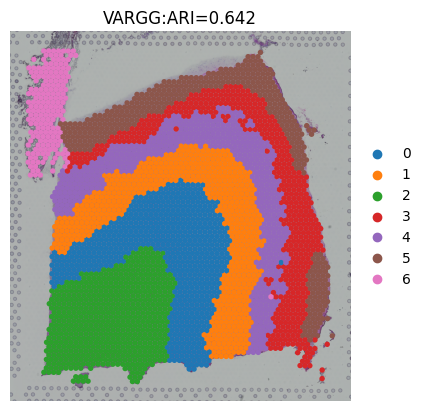

In [2]:
df_truth = pd.read_csv("/data/3/DeepST-main/DLPFC_annotations/151675_truth.txt", sep='\t', header=None, index_col=0)
adata.obs["GT"] = df_truth
df_obs = adata.obs.dropna()

# ARI
pred_ARI = adjusted_rand_score(df_obs["VARGG_domain"], df_obs['GT'])
refine_ARI = adjusted_rand_score(df_obs["VARGG_refine_domain"], df_obs['GT'])

# Spatial localization map of the spatial domain
sc.pl.spatial(adata, color='VARGG_refine_domain', frameon=False,spot_size=150,title=["VARGG:ARI={:.3f}".format(refine_ARI)])